<a href="https://colab.research.google.com/github/riddhikarlekar17/Data_Science_Lab_SE_A__26/blob/main/DS_prac_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import zipfile

with zipfile.ZipFile('archive(2).zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted successfully!")

Extracted successfully!


In [12]:
import os
print(os.listdir())


['.config', 'archive(2).zip', 'retail_sales_dataset.csv', 'sample_data']


In [13]:
import pandas as pd
df = pd.read_csv('retail_sales_dataset.csv')
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


Columns: Index(['TRANSACTION ID', 'DATE', 'CUSTOMER ID', 'GENDER', 'AGE',
       'PRODUCT CATEGORY', 'QUANTITY', 'PRICE PER UNIT', 'TOTAL AMOUNT'],
      dtype='object')
⚠️ REGION column not found → creating dummy region

--- SALES REPORT ---
Total Sales: 456000
Total Units Sold: 2514


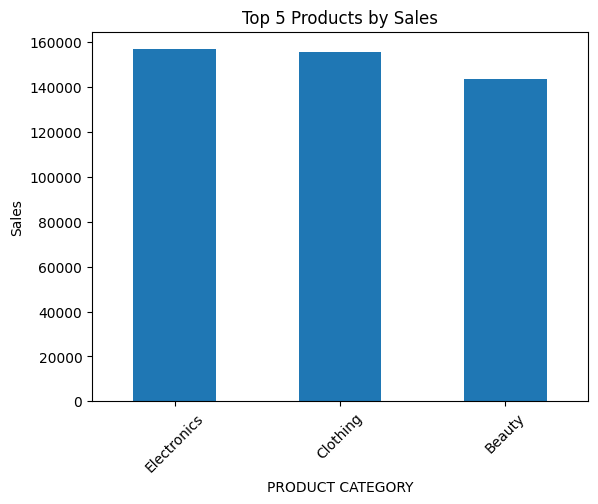

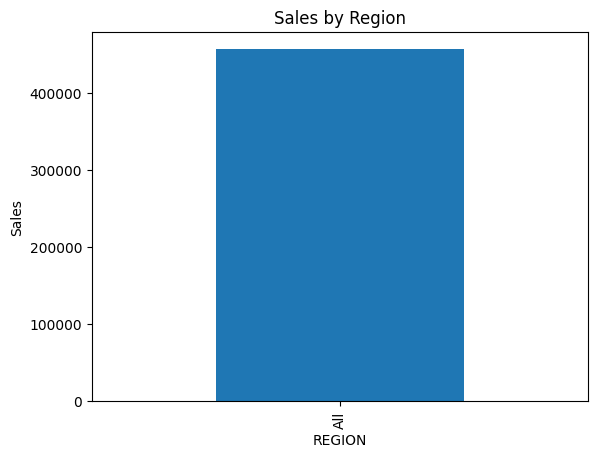

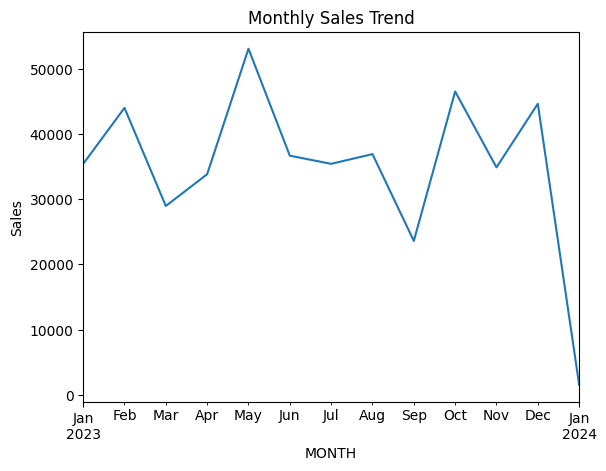

In [16]:
# ---------- IMPORT ----------
import pandas as pd
import matplotlib.pyplot as plt

# ---------- LOAD ----------
df = pd.read_csv('retail_sales_dataset.csv')

# ---------- CLEAN ----------
df.columns = df.columns.str.strip().str.upper()
print("Columns:", df.columns)

# ---------- COLUMN MAPPING ----------
date_col = 'DATE'
sales_col = 'TOTAL AMOUNT'
qty_col = 'QUANTITY'
product_col = 'PRODUCT CATEGORY'

# ---------- HANDLE REGION ----------
if 'REGION' in df.columns:
    region_col = 'REGION'
else:
    print("⚠️ REGION column not found → creating dummy region")
    df['REGION'] = 'All'
    region_col = 'REGION'

# ---------- DATE ----------
df[date_col] = pd.to_datetime(df[date_col])

# ---------- KPIs ----------
total_sales = df[sales_col].sum()
total_units = df[qty_col].sum()

print("\n--- SALES REPORT ---")
print("Total Sales:", total_sales)
print("Total Units Sold:", total_units)

# ---------- TOP PRODUCTS ----------
top_products = (
    df.groupby(product_col)[sales_col]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# ---------- SALES BY REGION ----------
sales_region = df.groupby(region_col)[sales_col].sum()

# ---------- MONTHLY TREND ----------
df['MONTH'] = df[date_col].dt.to_period('M')
monthly_sales = df.groupby('MONTH')[sales_col].sum()

# =====================================================
# 📊 VISUAL 1: TOP PRODUCTS
# =====================================================
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 5 Products by Sales")
plt.xticks(rotation=45)
plt.ylabel("Sales")
plt.show()

# =====================================================
# 📊 VISUAL 2: SALES BY REGION
# =====================================================
plt.figure()
sales_region.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

# =====================================================
# 📊 VISUAL 3: MONTHLY TREND
# =====================================================
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()